In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/osamac/ssh-logs-with-attack-classification/SSH.csv


In [2]:
import pandas as pd

In [19]:
data=pd.read_csv("/kaggle/input/datasets/osamac/ssh-logs-with-attack-classification/SSH.csv")
data

,user,is_private,is_failure,is_root,is_valid,not_valid_count,ip_failure,ip_success,no_failure,first,td,ts,class
0,kamran,1,1,0,1,0,1,0,2,1,0,1.544679e+09,0
1,kamran,1,1,0,1,0,2,0,3,0,18,1.544679e+09,0
2,student,1,0,0,1,0,0,1,0,0,133,1.544679e+09,0
3,kamran,1,1,0,1,0,1,1,2,0,58,1.544679e+09,0
4,kamran,1,1,0,1,0,2,1,3,0,29,1.544679e+09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,osamac,1,1,0,1,0,8,0,12,0,21,1.514931e+09,1
279,osamac,1,1,0,1,0,9,0,13,0,16,1.514931e+09,1
280,osamac,1,0,0,1,0,0,1,0,0,7,1.514931e+09,0
281,osamac,1,0,0,1,0,0,1,0,1,0,1.514959e+09,0


In [20]:
data['ts'].dtype

dtype('float64')

ts is unix timestamp

In [21]:
data.isnull().sum()

user               0
is_private         0
is_failure         0
is_root            0
is_valid           0
not_valid_count    0
ip_failure         0
ip_success         0
no_failure         0
first              0
td                 0
ts                 0
class              0
dtype: int64

In [22]:
data["class"].value_counts()

class
0    216
1     67
Name: count, dtype: int64

In [23]:
data["not_valid_count"].value_counts()

not_valid_count
0     200
1       9
2       8
3       7
4       5
5       5
6       5
7       4
8       4
9       4
10      4
11      3
12      3
13      3
14      3
15      1
16      1
17      1
18      1
19      1
20      1
21      1
22      1
23      1
24      1
25      1
26      1
27      1
28      1
29      1
30      1
Name: count, dtype: int64

In [25]:
data["dt"] = pd.to_datetime(data["ts"], unit="s")

data["hour"] = data["dt"].dt.hour
data["dayofweek"] = data["dt"].dt.dayofweek
data["day"] =data["dt"].dt.day
data["month"] =data["dt"].dt.month

In [26]:
data

,user,is_private,is_failure,is_root,is_valid,not_valid_count,ip_failure,ip_success,no_failure,first,td,ts,class,dt,hour,dayofweek,day,month
0,kamran,1,1,0,1,0,1,0,2,1,0,1.544679e+09,0,2018-12-13 05:22:00,5,3,13,12
1,kamran,1,1,0,1,0,2,0,3,0,18,1.544679e+09,0,2018-12-13 05:22:18,5,3,13,12
2,student,1,0,0,1,0,0,1,0,0,133,1.544679e+09,0,2018-12-13 05:24:31,5,3,13,12
3,kamran,1,1,0,1,0,1,1,2,0,58,1.544679e+09,0,2018-12-13 05:25:29,5,3,13,12
4,kamran,1,1,0,1,0,2,1,3,0,29,1.544679e+09,0,2018-12-13 05:25:58,5,3,13,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,osamac,1,1,0,1,0,8,0,12,0,21,1.514931e+09,1,2018-01-02 22:02:57,22,1,2,1
279,osamac,1,1,0,1,0,9,0,13,0,16,1.514931e+09,1,2018-01-02 22:03:13,22,1,2,1
280,osamac,1,0,0,1,0,0,1,0,0,7,1.514931e+09,0,2018-01-02 22:03:20,22,1,2,1
281,osamac,1,0,0,1,0,0,1,0,1,0,1.514959e+09,0,2018-01-03 06:03:26,6,2,3,1


In [27]:
data=data.drop(['dt','ts'],axis=1)
data

,user,is_private,is_failure,is_root,is_valid,not_valid_count,ip_failure,ip_success,no_failure,first,td,class,hour,dayofweek,day,month
0,kamran,1,1,0,1,0,1,0,2,1,0,0,5,3,13,12
1,kamran,1,1,0,1,0,2,0,3,0,18,0,5,3,13,12
2,student,1,0,0,1,0,0,1,0,0,133,0,5,3,13,12
3,kamran,1,1,0,1,0,1,1,2,0,58,0,5,3,13,12
4,kamran,1,1,0,1,0,2,1,3,0,29,0,5,3,13,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,osamac,1,1,0,1,0,8,0,12,0,21,1,22,1,2,1
279,osamac,1,1,0,1,0,9,0,13,0,16,1,22,1,2,1
280,osamac,1,0,0,1,0,0,1,0,0,7,0,22,1,2,1
281,osamac,1,0,0,1,0,0,1,0,1,0,0,6,2,3,1


In [28]:
import numpy as np

In [32]:
logs=['not_valid_count','ip_failure','ip_success','td','no_failure']

for col in logs:
    data[col]=np.log1p(data[col])

In [33]:
data

,user,is_private,is_failure,is_root,is_valid,not_valid_count,ip_failure,ip_success,no_failure,first,td,class,hour,dayofweek,day,month
0,kamran,1,1,0,1,0.0,0.526589,0.000000,1.098612,1,0.000000,0,5,3,13,12
1,kamran,1,1,0,1,0.0,0.741276,0.000000,1.386294,0,1.372307,0,5,3,13,12
2,student,1,0,0,1,0.0,0.000000,0.526589,0.000000,0,1.774586,0,5,3,13,12
3,kamran,1,1,0,1,0.0,0.526589,0.526589,1.098612,0,1.624826,0,5,3,13,12
4,kamran,1,1,0,1,0.0,0.741276,0.526589,1.386294,0,1.481877,0,5,3,13,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,osamac,1,1,0,1,0.0,1.162283,0.000000,2.564949,0,1.408800,1,22,1,2,1
279,osamac,1,1,0,1,0.0,1.194706,0.000000,2.639057,0,1.343703,1,22,1,2,1
280,osamac,1,0,0,1,0.0,0.000000,0.526589,0.000000,0,1.124748,0,22,1,2,1
281,osamac,1,0,0,1,0.0,0.000000,0.526589,0.000000,1,0.000000,0,6,2,3,1


In [35]:
data["user"].value_counts()

user
osamac      101
student      44
root         37
kamran       18
gtta         17
gta          16
admin         6
osamax        3
Maddock       2
adminx        2
newpass       2
piglet        1
phoenix       1
admins        1
Hockey        1
notused       1
passwd        1
abc123        1
runner        1
sam           1
rainbow       1
asshole       1
orange        1
tigger        1
wheeling      1
internet      1
Mickey        1
qwerty        1
fiction       1
computer      1
chris         1
Justin        1
money         1
jennifer      1
mustang       1
david         1
buster        1
foobar        1
fred          1
apple         1
stupid        1
jordan        1
harley        1
andrew        1
summer        1
sunshine      1
Name: count, dtype: int64

In [36]:
data['user']=data.groupby('user')['class'].transform("mean")
data

,user,is_private,is_failure,is_root,is_valid,not_valid_count,ip_failure,ip_success,no_failure,first,td,class,hour,dayofweek,day,month
0,0.111111,1,1,0,1,0.0,0.526589,0.000000,1.098612,1,0.000000,0,5,3,13,12
1,0.111111,1,1,0,1,0.0,0.741276,0.000000,1.386294,0,1.372307,0,5,3,13,12
2,0.045455,1,0,0,1,0.0,0.000000,0.526589,0.000000,0,1.774586,0,5,3,13,12
3,0.111111,1,1,0,1,0.0,0.526589,0.526589,1.098612,0,1.624826,0,5,3,13,12
4,0.111111,1,1,0,1,0.0,0.741276,0.526589,1.386294,0,1.481877,0,5,3,13,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,0.039604,1,1,0,1,0.0,1.162283,0.000000,2.564949,0,1.408800,1,22,1,2,1
279,0.039604,1,1,0,1,0.0,1.194706,0.000000,2.639057,0,1.343703,1,22,1,2,1
280,0.039604,1,0,0,1,0.0,0.000000,0.526589,0.000000,0,1.124748,0,22,1,2,1
281,0.039604,1,0,0,1,0.0,0.000000,0.526589,0.000000,1,0.000000,0,6,2,3,1


In [37]:
datac=data

In [38]:
datac

,user,is_private,is_failure,is_root,is_valid,not_valid_count,ip_failure,ip_success,no_failure,first,td,class,hour,dayofweek,day,month
0,0.111111,1,1,0,1,0.0,0.526589,0.000000,1.098612,1,0.000000,0,5,3,13,12
1,0.111111,1,1,0,1,0.0,0.741276,0.000000,1.386294,0,1.372307,0,5,3,13,12
2,0.045455,1,0,0,1,0.0,0.000000,0.526589,0.000000,0,1.774586,0,5,3,13,12
3,0.111111,1,1,0,1,0.0,0.526589,0.526589,1.098612,0,1.624826,0,5,3,13,12
4,0.111111,1,1,0,1,0.0,0.741276,0.526589,1.386294,0,1.481877,0,5,3,13,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,0.039604,1,1,0,1,0.0,1.162283,0.000000,2.564949,0,1.408800,1,22,1,2,1
279,0.039604,1,1,0,1,0.0,1.194706,0.000000,2.639057,0,1.343703,1,22,1,2,1
280,0.039604,1,0,0,1,0.0,0.000000,0.526589,0.000000,0,1.124748,0,22,1,2,1
281,0.039604,1,0,0,1,0.0,0.000000,0.526589,0.000000,1,0.000000,0,6,2,3,1


In [40]:
y=datac["class"]
x=datac.drop("class",axis=1)

In [41]:
print(x.shape)
print(y.shape)

(283, 15)
(283,)


In [45]:
data["class"].value_counts()

class
0    216
1     67
Name: count, dtype: int64

In [46]:
from sklearn.model_selection import train_test_split 

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [47]:
print(x_train.shape)
print(y_train.shape)

(226, 15)
(226,)


In [48]:
from xgboost import XGBClassifier

In [49]:
model=XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    eval_metric="logloss",
    random_state=42,
    colsample_bytree=0.8,
    subsample=0.8
)

In [55]:
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [57]:
pred=model.predict(x_test)
pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1])

In [58]:
y_test

110    1
147    0
252    0
55     0
59     0
173    0
191    0
25     0
250    0
103    1
139    0
265    0
277    1
278    1
93     1
69     1
159    0
90     1
62     0
186    0
217    0
208    0
163    0
281    0
187    0
53     0
213    1
223    0
63     0
68     0
156    0
267    0
83     0
138    0
272    0
242    0
251    0
178    0
1      0
237    0
24     0
74     1
100    1
42     0
57     0
282    0
160    0
232    0
218    1
94     1
261    0
164    0
18     0
9      1
86     0
206    0
276    0
Name: class, dtype: int64

In [60]:
import pandas as pd

output=pd.DataFrame({
    'actual':y_test,
    'predicted':pred,
    'same?':np.where(y_test == pred, 'yes', 'no')
})

In [61]:
output

,actual,predicted,same?
110,1,1,yes
147,0,0,yes
252,0,0,yes
55,0,0,yes
59,0,0,yes
173,0,0,yes
191,0,0,yes
25,0,0,yes
250,0,0,yes
103,1,1,yes


In [62]:
output['same?'].value_counts()

same?
yes    56
no      1
Name: count, dtype: int64

In [64]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        44
           1       0.93      1.00      0.96        13

    accuracy                           0.98        57
   macro avg       0.96      0.99      0.98        57
weighted avg       0.98      0.98      0.98        57



Text(0.5, 23.52222222222222, 'Predicted classes')

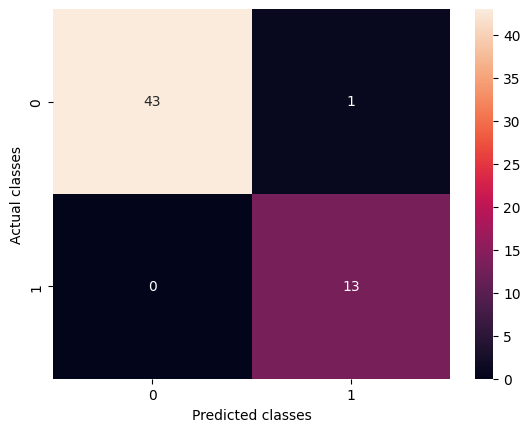

In [71]:
cm=confusion_matrix(y_test,pred)

sns.heatmap(cm, annot=True)
plt.ylabel('Actual classes')
plt.xlabel('Predicted classes')